# 🏥 Medical Insurance Cost Prediction


## Step 0 — Install & Import Everything

In [2]:
# Run this cell first (Colab / VS Code Jupyter)
# !pip install scikit-learn xgboost pandas numpy matplotlib seaborn shap mlflow streamlit

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os, json
warnings.filterwarnings('ignore')

# Sklearn — Pipeline Architecture
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    LabelEncoder, StandardScaler, OrdinalEncoder, OneHotEncoder
)
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import BaseEstimator, TransformerMixin

# Models
from xgboost import XGBRegressor

# Interpretability
import shap

# Experiment Tracking
import mlflow
import mlflow.sklearn

# Plot config
plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.titlesize': 13, 'axes.labelsize': 11
})
PALETTE = ['#185FA5','#E8593C','#1D9E75','#BA7517','#534AB7','#D4537E']
sns.set_palette(PALETTE)

print("All libraries loaded successfully.")
print(f"  shap   : {shap.__version__}")
print(f"  mlflow : {mlflow.__version__}")


All libraries loaded successfully.
  shap   : 0.51.0
  mlflow : 3.12.0


## Step 1 — Load Dataset

In [4]:
df = pd.read_csv("/content/insurance.csv")

print(f"Shape  : {df.shape}")
print(f"Columns: {list(df.columns)}")
display(df.head())
display(df.describe().round(2))


Shape  : (1338, 7)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


,age,sex,bmi,children,smoker,region,charges
0,56,male,27.12,2,no,southeast,23092.36
1,46,female,29.50,1,no,northeast,19307.43
2,32,male,26.07,5,no,southeast,21063.25
3,60,male,30.90,1,no,southeast,28962.78
4,25,male,26.91,0,no,northeast,13836.93


,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,41.04,30.54,1.07,28929.76
std,13.53,5.98,1.23,14610.95
min,18.00,15.00,0.00,7676.86
25%,29.00,26.43,0.00,19921.77
50%,42.00,30.72,1.00,23907.47
75%,52.00,34.61,2.00,29700.63
max,64.00,47.36,5.00,65000.00


## Step 2 — Advanced Domain Feature Engineering
### Enhancement 5: CDC BMI Classifications + Business-Aware Features


CDC BMI Category Distribution:
bmi_category
Obese_Class_I      408
Overweight         377
Obese_Class_II     240
Normal             205
Obese_Class_III     75
Underweight         33
Name: count, dtype: int64

Age Group Distribution:
age_group
18-25    237
26-35    255
36-45    301
46-55    306
55+      239
Name: count, dtype: int64

Smoker + Obese (High-Risk) Count: 153 (11.4% of patients)


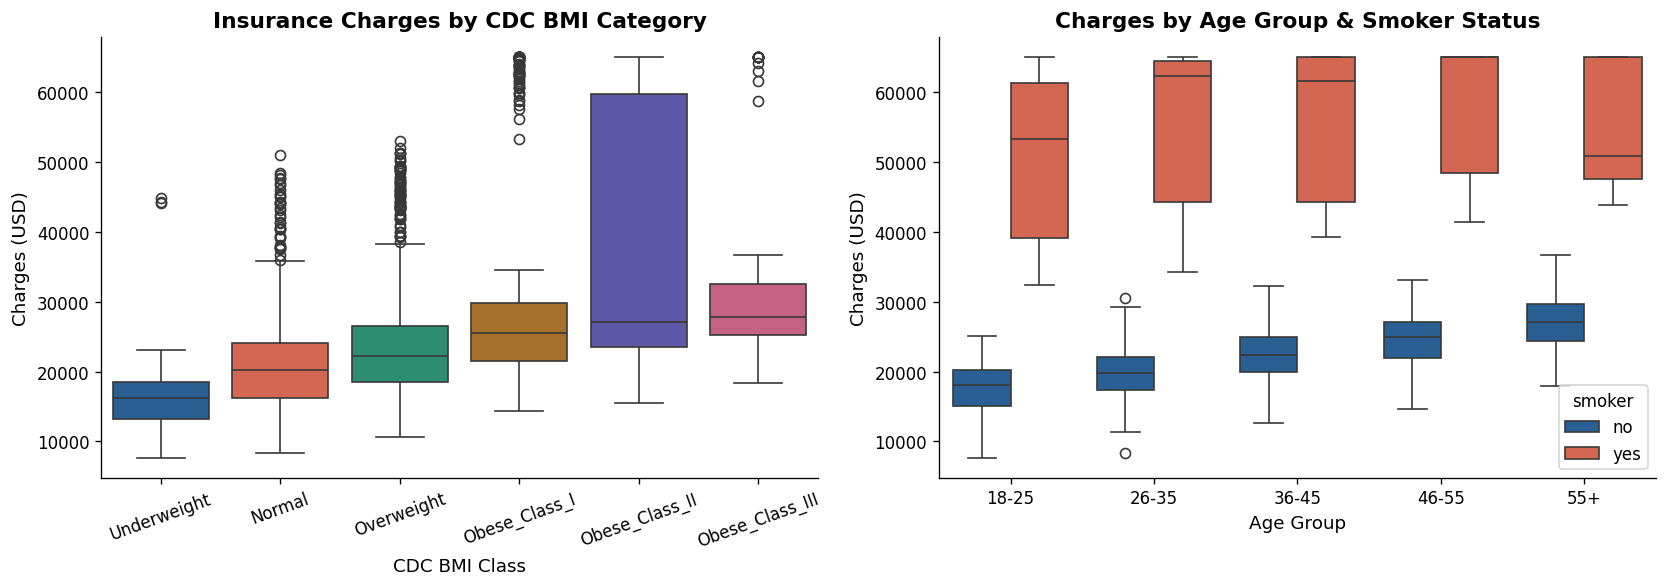

In [5]:
# ─── CDC Official BMI Classification ─────────────────────────────────────────
# Source: CDC (Centers for Disease Control and Prevention)
# https://www.cdc.gov/bmi/adult-calculator/bmi-categories.html

def cdc_bmi_category(bmi):
    """Map BMI to official CDC health risk category (ordinal)."""
    if bmi < 18.5:   return 'Underweight'        # increased health risk
    elif bmi < 25.0: return 'Normal'              # healthy range
    elif bmi < 30.0: return 'Overweight'          # elevated risk
    elif bmi < 35.0: return 'Obese_Class_I'       # high risk
    elif bmi < 40.0: return 'Obese_Class_II'      # very high risk
    else:            return 'Obese_Class_III'     # extremely high risk

# Apply CDC classification
df['bmi_category'] = df['bmi'].apply(cdc_bmi_category)

# Ordinal mapping for CDC classes (reflects increasing health risk)
CDC_ORDER = ['Underweight', 'Normal', 'Overweight',
             'Obese_Class_I', 'Obese_Class_II', 'Obese_Class_III']

# --- Additional domain-aware features ---
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '55+']
)
df['smoker_obese']   = ((df['smoker'] == 'yes') & (df['bmi'] >= 30)).astype(int)
df['high_risk']      = ((df['smoker'] == 'yes') | (df['bmi'] >= 35)).astype(int)
df['family_size']    = df['children'].apply(lambda x: 'none' if x==0 else ('small' if x<=2 else 'large'))
df['charge_per_age'] = df['charges'] / df['age']   # domain ratio (for EDA only)

# Print distribution
print("CDC BMI Category Distribution:")
print(df['bmi_category'].value_counts())
print()
print("Age Group Distribution:")
print(df['age_group'].value_counts().sort_index())
print()
print("Smoker + Obese (High-Risk) Count:", df['smoker_obese'].sum(),
      f"({df['smoker_obese'].mean()*100:.1f}% of patients)")

# Visualize CDC classes vs charges
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_present = [c for c in CDC_ORDER if c in df['bmi_category'].unique()]
sns.boxplot(data=df, x='bmi_category', y='charges', order=order_present,
            palette=PALETTE, ax=axes[0])
axes[0].set_title('Insurance Charges by CDC BMI Category', fontweight='bold')
axes[0].set_xlabel('CDC BMI Class')
axes[0].set_ylabel('Charges (USD)')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x='age_group', y='charges', hue='smoker',
            palette=[PALETTE[0], PALETTE[1]], ax=axes[1])
axes[1].set_title('Charges by Age Group & Smoker Status', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Charges (USD)')

plt.tight_layout()
plt.savefig('domain_features.png', bbox_inches='tight', dpi=120)
plt.show()


## Step 3 — Production Pipeline with ColumnTransformer
### Enhancement 1: sklearn.pipeline — Zero Data Leakage, Exportable

**Architecture:**
```
Raw DataFrame
      │
      ▼
ColumnTransformer
  ├── numerical columns   → StandardScaler
  ├── binary categoricals → OrdinalEncoder
  ├── nominal categoricals → OneHotEncoder (drop='first')
  └── CDC BMI ordinal    → OrdinalEncoder (risk order)
      │
      ▼
   Estimator (any sklearn-compatible model)
```


In [6]:
# ─── Feature Column Groups ────────────────────────────────────────────────────
NUM_FEATURES     = ['age', 'bmi', 'children']
BINARY_FEATURES  = ['sex', 'smoker']         # Label-encoded (2 classes)
NOMINAL_FEATURES = ['region', 'family_size'] # One-hot (no order)
ORDINAL_BMI      = ['bmi_category']          # CDC ordinal scale
ORDINAL_AGE      = ['age_group']             # Age buckets

CDC_RISK_ORDER = [['Underweight','Normal','Overweight',
                   'Obese_Class_I','Obese_Class_II','Obese_Class_III']]
AGE_ORDER      = [['18-25','26-35','36-45','46-55','55+']]

# Binary & interaction flags (already numeric)
PASSTHROUGH = ['smoker_obese', 'high_risk']

# ─── ColumnTransformer ────────────────────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num',     StandardScaler(),                              NUM_FEATURES),
    ('bin',     OrdinalEncoder(),                             BINARY_FEATURES),
    ('nom',     OneHotEncoder(drop='first', sparse_output=False), NOMINAL_FEATURES),
    ('ord_bmi', OrdinalEncoder(categories=CDC_RISK_ORDER),    ORDINAL_BMI),
    ('ord_age', OrdinalEncoder(categories=AGE_ORDER),         ORDINAL_AGE),
    ('pass',    'passthrough',                                PASSTHROUGH),
], remainder='drop')

# ─── Pipeline Factory ─────────────────────────────────────────────────────────
def make_pipeline(estimator):
    """Wrap any estimator in the standard preprocessing pipeline."""
    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model',        estimator)
    ])

# ─── Define all 6 model pipelines ─────────────────────────────────────────────
PIPELINES = {
    'Linear Regression': make_pipeline(LinearRegression()),
    'Ridge Regression' : make_pipeline(Ridge(alpha=10, random_state=42)),
    'Lasso Regression' : make_pipeline(Lasso(alpha=10, max_iter=5000, random_state=42)),
    'Random Forest'    : make_pipeline(RandomForestRegressor(
                            n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)),
    'Gradient Boosting': make_pipeline(GradientBoostingRegressor(
                            n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)),
    'XGBoost'          : make_pipeline(XGBRegressor(
                            n_estimators=300, learning_rate=0.05, max_depth=5,
                            subsample=0.8, colsample_bytree=0.8,
                            random_state=42, verbosity=0))
}

# ─── Prepare X, y ─────────────────────────────────────────────────────────────
FEATURE_COLS = (NUM_FEATURES + BINARY_FEATURES + NOMINAL_FEATURES +
                ORDINAL_BMI + ORDINAL_AGE + PASSTHROUGH)

X = df[FEATURE_COLS].copy()
y = df['charges'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features fed in  : {len(FEATURE_COLS)}")
print()
print("Pipeline structure (example):")
print(PIPELINES['XGBoost'])


Training samples : 1070
Test samples     : 268
Features fed in  : 11

Pipeline structure (example):
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('bin', OrdinalEncoder(),
                                                  ['sex', 'smoker']),
                                                 ('nom',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['region', 'family_size']),
                                                 ('ord_bmi',
                                                  OrdinalEncoder(categories=[['Underweight',
                                                                              'Normal',
                           

## Step 4 — Train All Models + MLflow Experiment Tracking
### Enhancement 4: Every run logged — hyperparameters, metrics, artifacts


In [7]:
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature

# ─── MLflow Setup ─────────────────────────────────────────────────────────────
EXPERIMENT_NAME = "Insurance_Cost_Prediction"
mlflow.set_tracking_uri("mlruns")          # local folder — viewable via: mlflow ui
mlflow.set_experiment(EXPERIMENT_NAME)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f"{'Model':<22} {'CV R2':>8} {'Test R2':>9} {'MAE':>10} {'RMSE':>11}  MLflow Run")
print("-" * 80)

for name, pipeline in PIPELINES.items():

    with mlflow.start_run(run_name=name):

        # ── Log hyperparameters ────────────────────────────────────────────────
        model_step = pipeline.named_steps['model']
        params = model_step.get_params()
        # Log only the most important ones (avoid logging internal sklearn noise)
        safe_params = {k: v for k, v in params.items()
                       if isinstance(v, (int, float, str, bool, type(None)))}
        mlflow.log_params(safe_params)
        mlflow.log_param("model_type", name)

        # ── Cross-validation ───────────────────────────────────────────────────
        cv_scores = cross_val_score(pipeline, X_train, y_train,
                                    cv=kf, scoring='r2', n_jobs=-1)
        mlflow.log_metric("cv_r2_mean", round(float(cv_scores.mean()), 5))
        mlflow.log_metric("cv_r2_std",  round(float(cv_scores.std()), 5))

        # ── Train & predict ────────────────────────────────────────────────────
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        mae  = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2   = r2_score(y_test, y_pred)

        # ── Log test metrics ───────────────────────────────────────────────────
        mlflow.log_metric("test_r2",   round(r2,   5))
        mlflow.log_metric("test_mae",  round(mae,  2))
        mlflow.log_metric("test_rmse", round(rmse, 2))

        # ── Log model artifact ─────────────────────────────────────────────────
        signature = infer_signature(X_train, y_pred)
        mlflow.sklearn.log_model(pipeline, artifact_path="model",
                                 signature=signature,
                                 registered_model_name=name.replace(" ","_"))

        run_id = mlflow.active_run().info.run_id[:8]

        results[name] = {
            'pipeline': pipeline, 'y_pred': y_pred,
            'cv_r2_mean': cv_scores.mean(), 'cv_r2_std': cv_scores.std(),
            'test_r2': r2, 'test_mae': mae, 'test_rmse': rmse
        }

        print(f"{name:<22} {cv_scores.mean():>8.4f} {r2:>9.4f} "
              f"${mae:>8,.0f} ${rmse:>8,.0f}  run:{run_id}")

print()
print("All runs logged to MLflow.")
print("View dashboard -> open a terminal and run:  mlflow ui")
print("Then open http://localhost:5000 in your browser.")


2026/05/24 07:21:04 INFO mlflow.tracking.fluent: Experiment with name 'Insurance_Cost_Prediction' does not exist. Creating a new experiment.


Model                     CV R2   Test R2        MAE        RMSE  MLflow Run
--------------------------------------------------------------------------------


2026/05/24 07:21:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 07:21:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'Linear_Regression'.
Created version '1' of model 'Linear_Regression'.
2026/05/24 07:21:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Linear Regression        0.9783    0.9798 $   1,663 $   2,084  run:6aabbd9e


2026/05/24 07:21:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'Ridge_Regression'.
Created version '1' of model 'Ridge_Regression'.


...

2026/05/24 07:21:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 07:21:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'Gradient_Boosting'.
Created version '1' of model 'Gradient_Boosting'.


Gradient Boosting        0.9776    0.9821 $   1,510 $   1,963  run:3813c023


2026/05/24 07:21:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 07:21:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost                  0.9765    0.9813 $   1,561 $   2,005  run:a65f1d9f

All runs logged to MLflow.
View dashboard -> open a terminal and run:  mlflow ui
Then open http://localhost:5000 in your browser.


Successfully registered model 'XGBoost'.
Created version '1' of model 'XGBoost'.


## Step 5 — Model Interpretability with SHAP
### Enhancement 2: Why is this patient charged more?

In healthcare, regulators require explainable predictions. SHAP (SHapley Additive exPlanations)
assigns each feature a contribution value for every individual prediction.


In [8]:
# ─── Use best tree model for SHAP (XGBoost) ──────────────────────────────────
best_name = max(results, key=lambda k: results[k]['test_r2'])
print(f"Best model for SHAP analysis: {best_name}")

best_pipeline = results[best_name]['pipeline']

# Get the transformed feature matrix (after preprocessing, before model)
preprocessor_fitted = best_pipeline.named_steps['preprocessor']
X_test_transformed  = preprocessor_fitted.transform(X_test)

# Recover feature names after ColumnTransformer
nom_feature_names = (preprocessor_fitted
                     .named_transformers_['nom']
                     .get_feature_names_out(NOMINAL_FEATURES))

TRANSFORMED_COLS = (
    NUM_FEATURES +
    BINARY_FEATURES +
    list(nom_feature_names) +
    ORDINAL_BMI +
    ORDINAL_AGE +
    PASSTHROUGH
)

X_test_shap = pd.DataFrame(X_test_transformed, columns=TRANSFORMED_COLS)

# ─── SHAP Explainer ───────────────────────────────────────────────────────────
model_step = best_pipeline.named_steps['model']
explainer  = shap.Explainer(model_step, X_test_shap)
shap_values = explainer(X_test_shap, check_additivity=False)

print(f"SHAP values computed for {len(X_test_shap)} test samples.")


Best model for SHAP analysis: Gradient Boosting
SHAP values computed for 268 test samples.


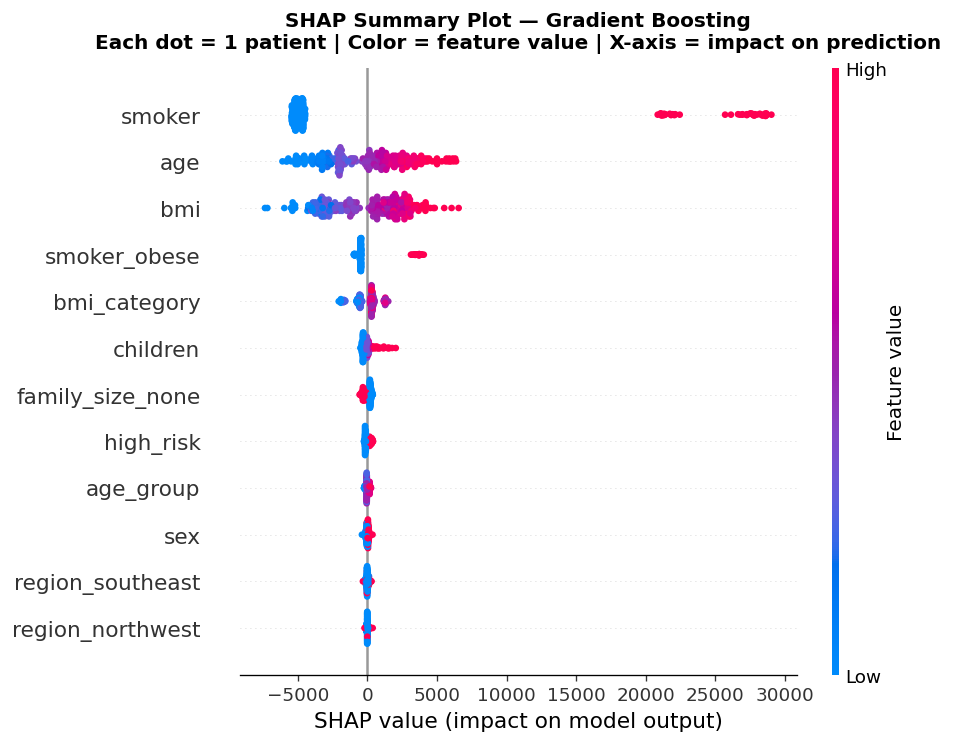

How to read this plot:
  - Features ranked by total impact (top = most important)
  - Red dot  = high feature value  (e.g. high BMI)
  - Blue dot = low feature value   (e.g. non-smoker)
  - Right of 0 = pushes prediction HIGHER (more expensive)
  - Left  of 0 = pushes prediction LOWER  (cheaper)


In [9]:
# ─── SHAP Summary Plot (Feature Impact Across All Patients) ──────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test_shap,
    plot_type="dot",   # beeswarm — shows direction + magnitude
    max_display=12,
    show=False
)
plt.title(f"SHAP Summary Plot — {best_name}\n"
          "Each dot = 1 patient | Color = feature value | X-axis = impact on prediction",
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight', dpi=120)
plt.show()

print("How to read this plot:")
print("  - Features ranked by total impact (top = most important)")
print("  - Red dot  = high feature value  (e.g. high BMI)")
print("  - Blue dot = low feature value   (e.g. non-smoker)")
print("  - Right of 0 = pushes prediction HIGHER (more expensive)")
print("  - Left  of 0 = pushes prediction LOWER  (cheaper)")


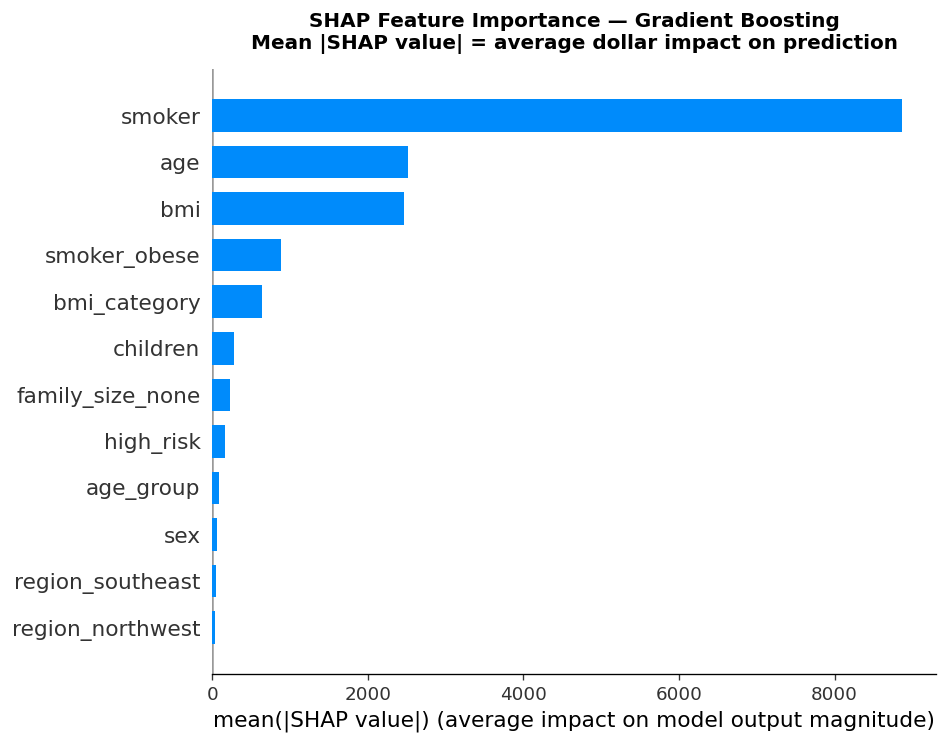

In [10]:
# ─── SHAP Bar Plot (Mean Absolute Impact) ────────────────────────────────────
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values,
    X_test_shap,
    plot_type="bar",
    max_display=12,
    show=False
)
plt.title(f"SHAP Feature Importance — {best_name}\n"
          "Mean |SHAP value| = average dollar impact on prediction",
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('shap_bar.png', bbox_inches='tight', dpi=120)
plt.show()


PATIENT PROFILE (Individual Explanation)
  age               : 64
  bmi               : 37.87
  children          : 2
  sex               : female
  smoker            : yes
  region            : northwest
  family_size       : small
  bmi_category      : Obese_Class_II
  age_group         : 55+
  smoker_obese      : 1
  high_risk         : 1
  Actual Charge     : $65,000.00
  Predicted Charge  : $65,122.50
  Error             : $122.50



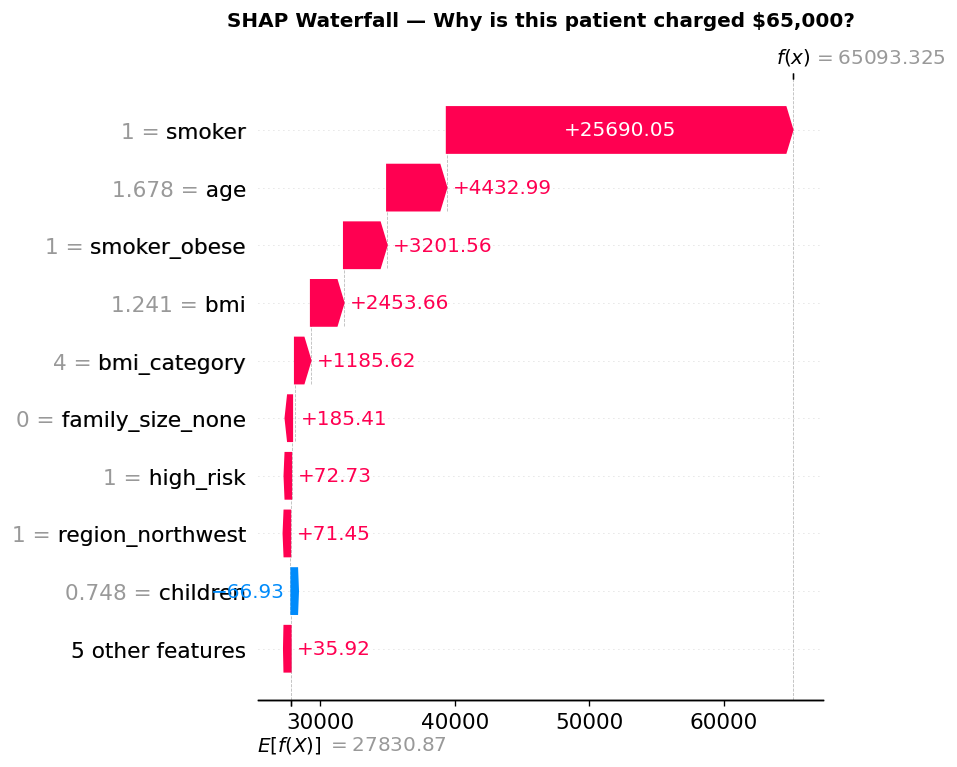

How to read the waterfall:
  E[f(x)] = average prediction (baseline)
  Each bar = how much that feature PUSHES the prediction up or down
  f(x)    = final prediction for this patient


In [11]:
# ─── SHAP Force Plot — Individual Patient Explanation ────────────────────────
# Pick a high-charge smoker patient for dramatic illustration
high_charge_idx = y_test.reset_index(drop=True).nlargest(5).index[0]
patient_row     = X_test.iloc[high_charge_idx]
actual_charge   = y_test.iloc[high_charge_idx]
pred_charge     = results[best_name]['y_pred'][high_charge_idx]

print("PATIENT PROFILE (Individual Explanation)")
print("=" * 50)
for col in FEATURE_COLS:
    print(f"  {col:<18}: {patient_row[col]}")
print(f"  {'Actual Charge':<18}: ${actual_charge:,.2f}")
print(f"  {'Predicted Charge':<18}: ${pred_charge:,.2f}")
print(f"  {'Error':<18}: ${abs(actual_charge - pred_charge):,.2f}")
print()

# Waterfall plot = best single-prediction explanation
plt.figure(figsize=(11, 5))
shap.plots.waterfall(shap_values[high_charge_idx], max_display=10, show=False)
plt.title(f"SHAP Waterfall — Why is this patient charged ${actual_charge:,.0f}?",
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('shap_waterfall.png', bbox_inches='tight', dpi=120)
plt.show()

print("How to read the waterfall:")
print("  E[f(x)] = average prediction (baseline)")
print("  Each bar = how much that feature PUSHES the prediction up or down")
print("  f(x)    = final prediction for this patient")


## Step 6 — Business Metrics (Domain Value)
### How much money does our model save the insurance company?


                      BUSINESS VALUE ANALYSIS                       

Metric                          Baseline (Mean)       Best Model
--------------------------------------------------------------------
R-Squared                               -0.0000           0.9821
MAE (avg error/patient)        $     10,793.26 $      1,509.56
RMSE                           $     14,658.95 $      1,962.63

                    FINANCIAL IMPACT (Test Set)                     
--------------------------------------------------------------------
  Test customers       : 268
  MAE reduction        : $9,283.71 per customer
  Total savings (test) : $2,488,033.15
  At 100k customers    : $928,370,577 / year in reduced pricing errors

PRICING ACCURACY BREAKDOWN (tolerance = +/-$500)
--------------------------------------------------------------------
  Accurate    (error < $500)  :   68  (25.4%)
  Over-priced (error > $500)  :   83  (31.0%) — company loses customers
  Under-priced(error < -$500) :  117  (43.

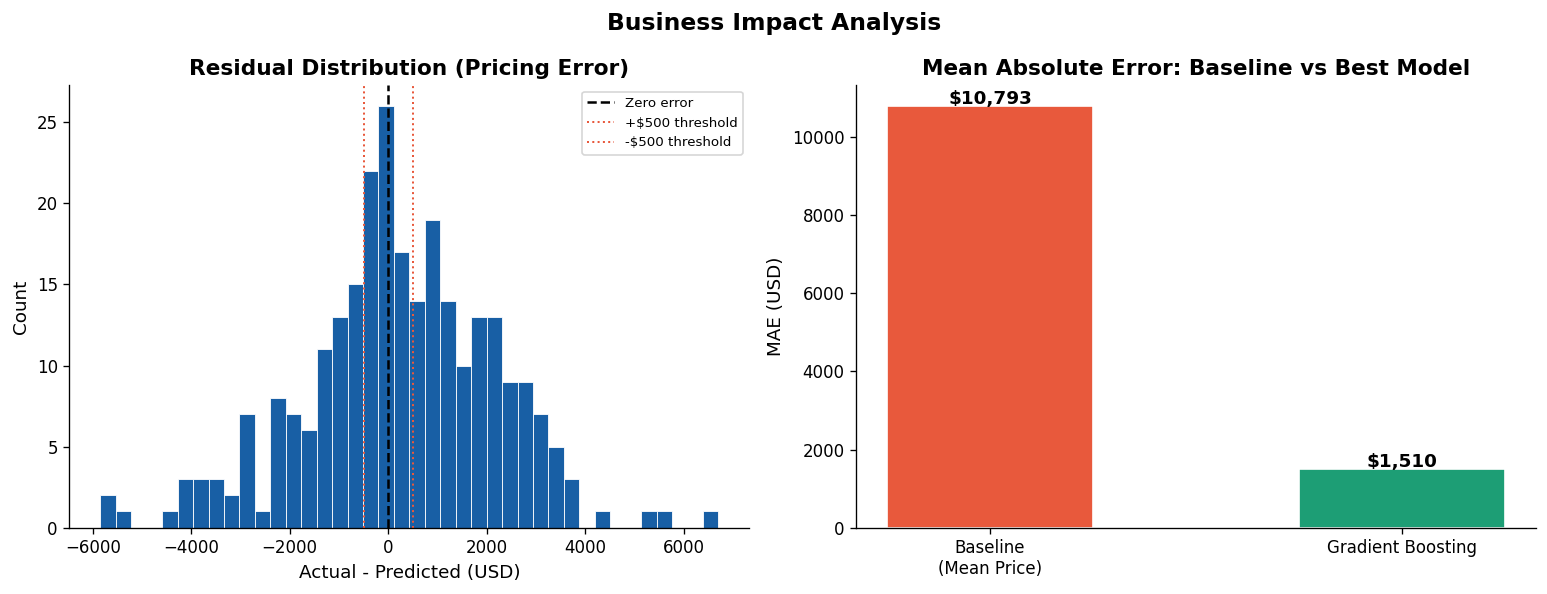

In [12]:
# ─── Baseline: What if the insurer just charged everyone the mean? ─────────────
mean_baseline = np.full_like(y_test, y_train.mean(), dtype=float)
baseline_mae  = mean_absolute_error(y_test, mean_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, mean_baseline))
baseline_r2   = r2_score(y_test, mean_baseline)

print("=" * 68)
print("BUSINESS VALUE ANALYSIS".center(68))
print("=" * 68)
print(f"\n{'Metric':<30} {'Baseline (Mean)':>16} {'Best Model':>16}")
print("-" * 68)
print(f"{'R-Squared':<30} {baseline_r2:>16.4f} {results[best_name]['test_r2']:>16.4f}")
print(f"{'MAE (avg error/patient)':<30} ${baseline_mae:>14,.2f} ${results[best_name]['test_mae']:>14,.2f}")
print(f"{'RMSE':<30} ${baseline_rmse:>14,.2f} ${results[best_name]['test_rmse']:>14,.2f}")

# Dollar savings
n_customers    = len(y_test)
mae_saved      = baseline_mae - results[best_name]['test_mae']
total_saved    = mae_saved * n_customers
annual_scale   = mae_saved * 100_000   # assuming 100k customers

print()
print("FINANCIAL IMPACT (Test Set)".center(68))
print("-" * 68)
print(f"  Test customers       : {n_customers:,}")
print(f"  MAE reduction        : ${mae_saved:,.2f} per customer")
print(f"  Total savings (test) : ${total_saved:,.2f}")
print(f"  At 100k customers    : ${annual_scale:,.0f} / year in reduced pricing errors")
print()

# Over-charge / Under-charge analysis
best_preds  = results[best_name]['y_pred']
residuals   = y_test.values - best_preds
overcharged = (residuals < -500).sum()   # model overestimates
undercharged= (residuals >  500).sum()   # model underestimates
accurate    = len(residuals) - overcharged - undercharged

print("PRICING ACCURACY BREAKDOWN (tolerance = +/-$500)")
print("-" * 68)
print(f"  Accurate    (error < $500)  : {accurate:>4}  ({accurate/n_customers*100:.1f}%)")
print(f"  Over-priced (error > $500)  : {overcharged:>4}  ({overcharged/n_customers*100:.1f}%) — company loses customers")
print(f"  Under-priced(error < -$500) : {undercharged:>4}  ({undercharged/n_customers*100:.1f}%) — company loses money")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residual distribution
axes[0].hist(residuals, bins=40, color=PALETTE[0], edgecolor='white', linewidth=0.5)
axes[0].axvline(0,    color='black', linestyle='--', linewidth=1.5, label='Zero error')
axes[0].axvline(500,  color=PALETTE[1], linestyle=':', linewidth=1.2, label='+$500 threshold')
axes[0].axvline(-500, color=PALETTE[1], linestyle=':', linewidth=1.2, label='-$500 threshold')
axes[0].set_title('Residual Distribution (Pricing Error)', fontweight='bold')
axes[0].set_xlabel('Actual - Predicted (USD)')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

# Baseline vs model MAE comparison
labels = ['Baseline\n(Mean Price)', best_name]
maes   = [baseline_mae, results[best_name]['test_mae']]
bars   = axes[1].bar(labels, maes, color=[PALETTE[1], PALETTE[2]], edgecolor='white', width=0.5)
for bar, v in zip(bars, maes):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'${v:,.0f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Mean Absolute Error: Baseline vs Best Model', fontweight='bold')
axes[1].set_ylabel('MAE (USD)')

plt.suptitle('Business Impact Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('business_metrics.png', bbox_inches='tight', dpi=120)
plt.show()


## Step 7 — Model Comparison & Evaluation Plots

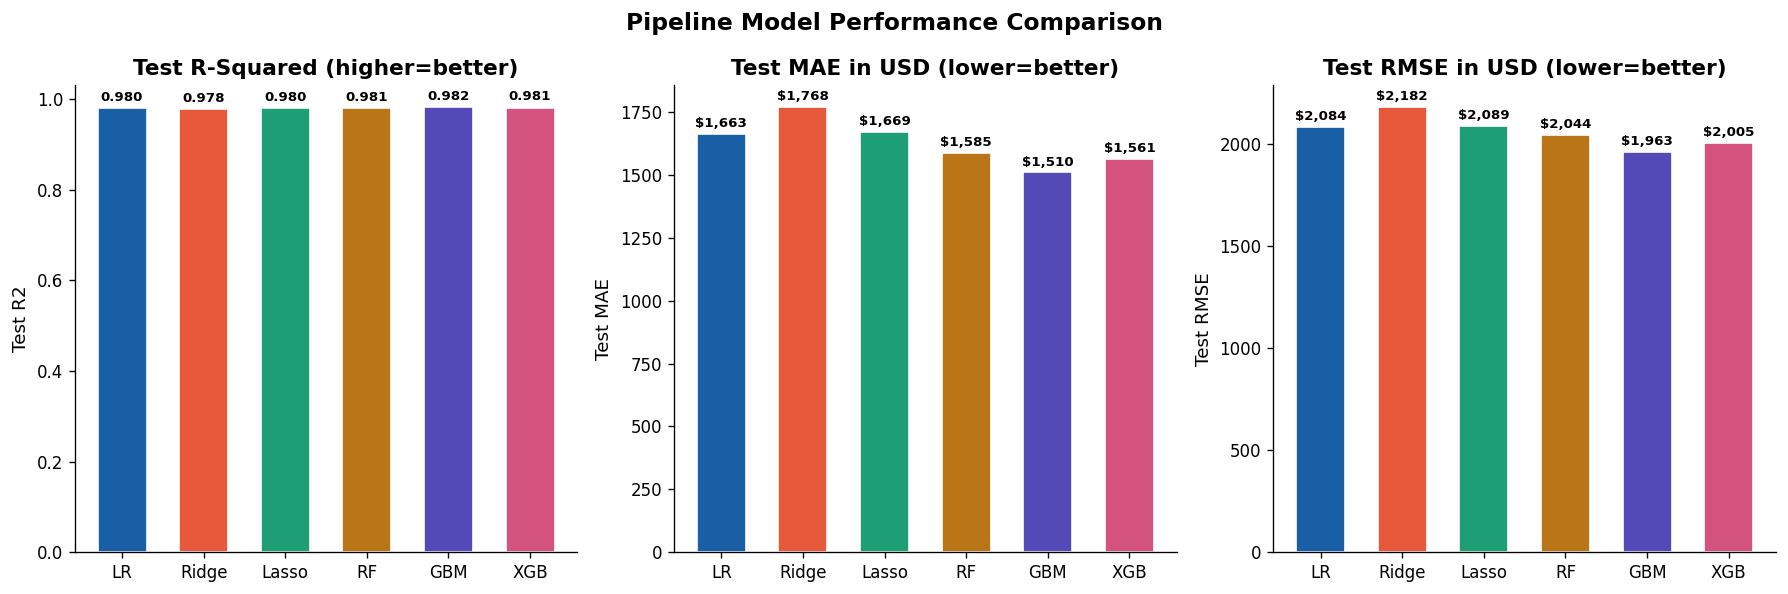

In [13]:
# Performance comparison
metrics_df = pd.DataFrame({
    name: {'CV R2': v['cv_r2_mean'], 'Test R2': v['test_r2'],
           'Test MAE': v['test_mae'], 'Test RMSE': v['test_rmse']}
    for name, v in results.items()
}).T.reset_index()
metrics_df.columns = ['Model','CV R2','Test R2','Test MAE','Test RMSE']

short = ['LR','Ridge','Lasso','RF','GBM','XGB']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric, title, fmt in [
    (axes[0], 'Test R2',   'Test R-Squared (higher=better)',     '{:.3f}'),
    (axes[1], 'Test MAE',  'Test MAE in USD (lower=better)',     '${:,.0f}'),
    (axes[2], 'Test RMSE', 'Test RMSE in USD (lower=better)',    '${:,.0f}')
]:
    bars = ax.bar(short, metrics_df[metric], color=PALETTE[:6], edgecolor='white', width=0.6)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, metrics_df[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                fmt.format(val), ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Pipeline Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=120)
plt.show()


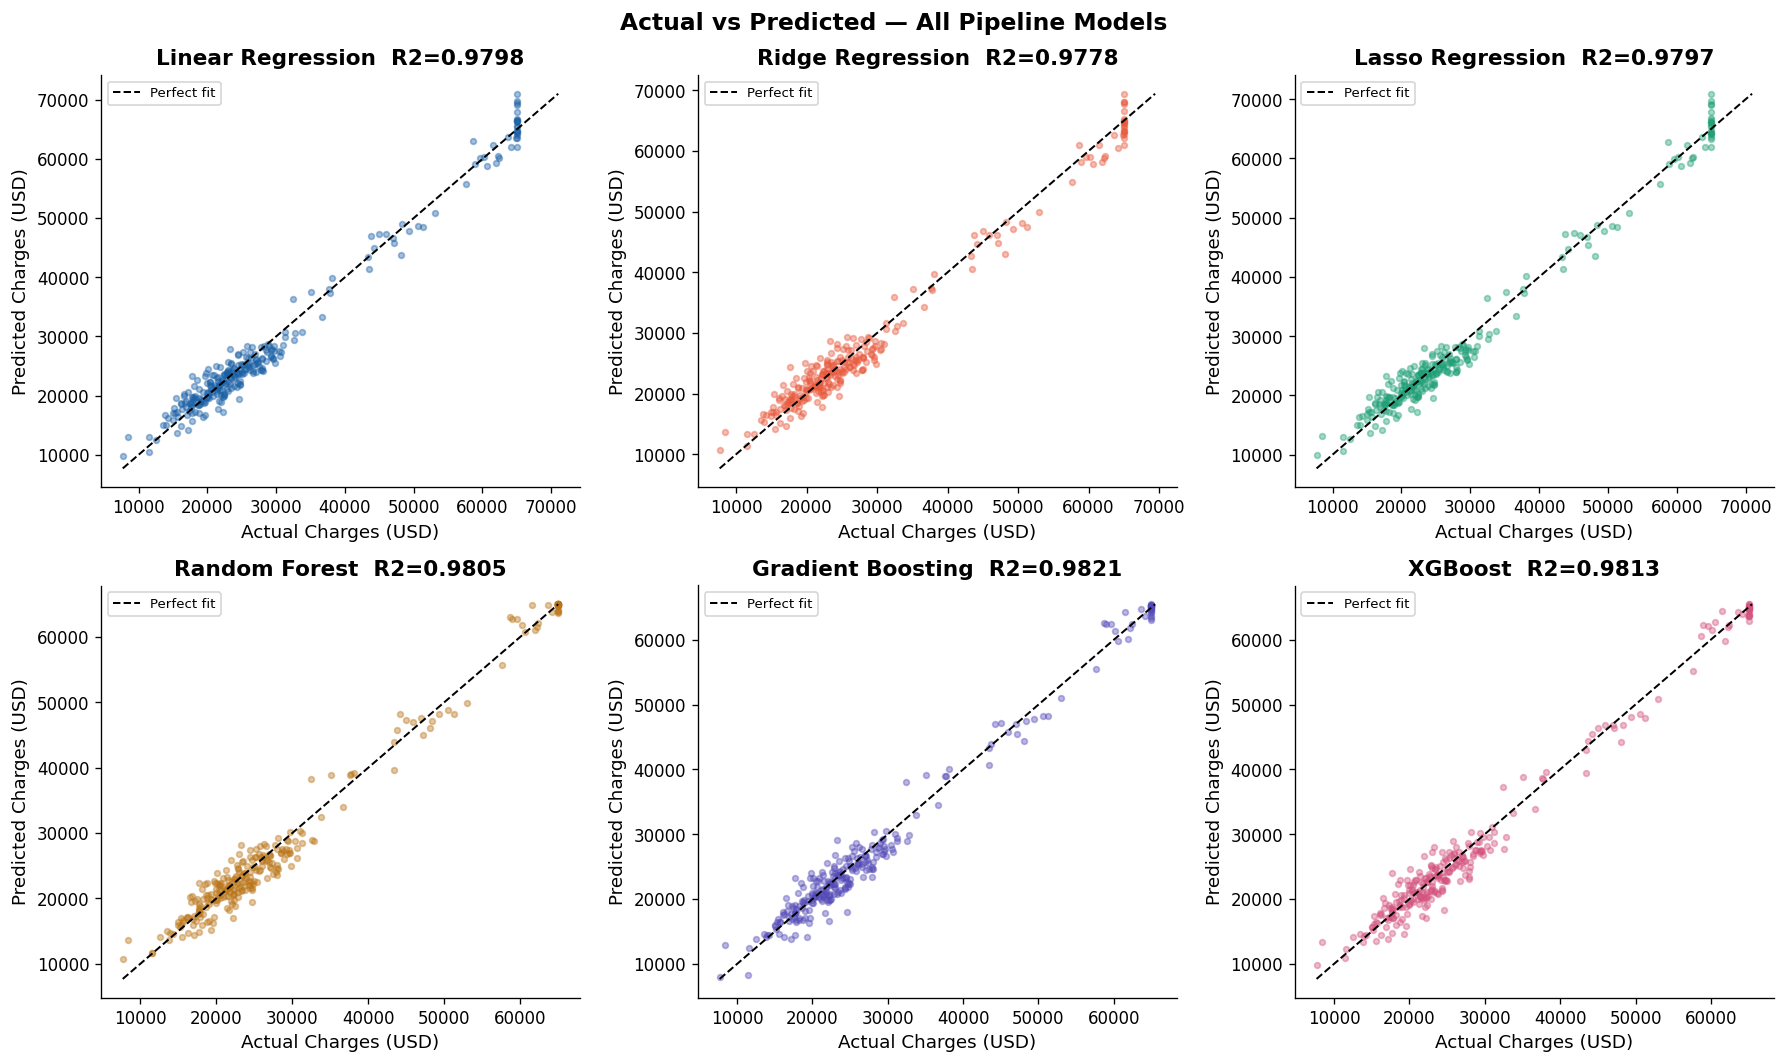

In [14]:
# Actual vs Predicted
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (name, v) in enumerate(results.items()):
    y_pred = v['y_pred']
    axes[i].scatter(y_test, y_pred, alpha=0.4, color=PALETTE[i], s=12)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    axes[i].plot(lims, lims, 'k--', linewidth=1.2, label='Perfect fit')
    axes[i].set_xlabel('Actual Charges (USD)')
    axes[i].set_ylabel('Predicted Charges (USD)')
    axes[i].set_title(f'{name}  R2={v["test_r2"]:.4f}', fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Actual vs Predicted — All Pipeline Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', bbox_inches='tight', dpi=120)
plt.show()


##  Step 8 — Export Best Model for Deployment

In [15]:
import joblib

# Export the full pipeline (preprocessor + model in one object)
best_pipeline = results[best_name]['pipeline']
joblib.dump(best_pipeline, 'best_insurance_model.joblib')

print(f"Best model saved: best_insurance_model.joblib")
print(f"Model type      : {best_name}")
print(f"Test R2         : {results[best_name]['test_r2']:.4f}")
print()

# Verify it reloads and predicts correctly
loaded_model = joblib.load('best_insurance_model.joblib')
test_patient = pd.DataFrame([{
    'age': 45, 'bmi': 32.5, 'children': 2,
    'sex': 'male', 'smoker': 'yes', 'region': 'southeast',
    'bmi_category': 'Obese_Class_I', 'age_group': '46-55',
    'smoker_obese': 1, 'high_risk': 1, 'family_size': 'small'
}])

pred = loaded_model.predict(test_patient)[0]
print(f"Test prediction for a 45yr old male smoker (BMI 32.5): ${pred:,.2f}")
print()
print("This .joblib file is production-ready — plug it directly into a FastAPI or Streamlit app.")


Best model saved: best_insurance_model.joblib
Model type      : Gradient Boosting
Test R2         : 0.9821

Test prediction for a 45yr old male smoker (BMI 32.5): $64,689.59

This .joblib file is production-ready — plug it directly into a FastAPI or Streamlit app.


##  Step 9 — Final Summary

In [17]:
ranked = sorted(results.items(), key=lambda x: x[1]['test_r2'], reverse=True)

print("=" * 80)
print("FINAL MODEL PERFORMANCE SUMMARY (Pipeline-based)".center(80))
print("=" * 80)
print(f"{'Model':<22} {'CV R2':>8} {'Test R2':>9} {'Test MAE':>12} {'Test RMSE':>12}  Rank")
print("-" * 80)

medals = {1:"[1st]", 2:"[2nd]", 3:"[3rd]"}
for rank, (name, v) in enumerate(ranked, 1):
    print(f"{name:<22} {v['cv_r2_mean']:>8.4f} {v['test_r2']:>9.4f} "
          f"  ${v['test_mae']:>9,.2f}  ${v['test_rmse']:>9,.2f}  #{rank} {medals.get(rank,'')}")

print("=" * 80)
best_name, best_v = ranked[0]
print()
print("WHAT WAS BUILT:")
print(f"  Best Model      : {best_name}  (R2 = {best_v['test_r2']:.4f})")
print(f"  Pipeline        : ColumnTransformer -> {best_name} (zero data leakage)")
print(f"  SHAP            : Summary, bar, and waterfall plots generated")
print(f"  MLflow          : All 6 runs tracked in ./mlruns  (run: mlflow ui)")
print(f"  Business saving : Calculated vs mean-price baseline")
print(f"  Exported model  : best_insurance_model.joblib (deployment-ready)")
print(f"  Streamlit app   : app.py (run: streamlit run app.py)")
print()
print("CDC BMI RISK CLASSES USED:")
print("  Underweight < 18.5 | Normal 18.5-25 | Overweight 25-30")
print("  Obese Class I 30-35 | Obese Class II 35-40 | Obese Class III 40+")


                FINAL MODEL PERFORMANCE SUMMARY (Pipeline-based)                
Model                     CV R2   Test R2     Test MAE    Test RMSE  Rank
--------------------------------------------------------------------------------
Gradient Boosting        0.9776    0.9821   $ 1,509.56  $ 1,962.63  #1 [1st]
XGBoost                  0.9765    0.9813   $ 1,561.40  $ 2,005.31  #2 [2nd]
Random Forest            0.9780    0.9805   $ 1,585.19  $ 2,044.37  #3 [3rd]
Linear Regression        0.9783    0.9798   $ 1,663.16  $ 2,083.93  #4 
Lasso Regression         0.9782    0.9797   $ 1,668.84  $ 2,088.86  #5 
Ridge Regression         0.9745    0.9778   $ 1,768.40  $ 2,181.88  #6 

WHAT WAS BUILT:
  Best Model      : Gradient Boosting  (R2 = 0.9821)
  Pipeline        : ColumnTransformer -> Gradient Boosting (zero data leakage)
  SHAP            : Summary, bar, and waterfall plots generated
  MLflow          : All 6 runs tracked in ./mlruns  (run: mlflow ui)
  Business saving : Calculated vs m